# 🏆 Sports Recommendation System
## Hybrid Model: Content-Based Filtering + Collaborative Filtering

---

### 📌 Project Overview

This notebook builds a **Hybrid Sports Recommendation System** that combines:
- **Content-Based Filtering** → recommends sports based on user profile features (age, goal, fitness level...)
- **Collaborative Filtering** → recommends sports based on similar users' ratings and behavior
- **Hybrid Ensemble** → combines both models for superior accuracy

### 📊 Pipeline
```
Raw Data → EDA → Preprocessing → Content-Based Model → Collaborative Model → Hybrid → Evaluation
```

---
## 📦 Section 1: Import Libraries

In [2]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Content-Based Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import cosine_similarity
from xgboost import XGBClassifier

# Collaborative Filtering
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

# Utilities
import joblib
import os

print('✅ All libraries imported successfully!')
print(f'📊 Pandas version: {pd.__version__}')
print(f'🤖 Sklearn imported')

✅ All libraries imported successfully!
📊 Pandas version: 2.3.2
🤖 Sklearn imported


---
## 📂 Section 2: Load & Explore Data

In [3]:
# ============================================================
# Load Dataset — Strict Rules v2 (66,000 rows + 5 new features)
# ============================================================
df = pd.read_csv('sports_data_strict_v2.csv')

print('=' * 65)
print(f'  Dataset Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Sports         : {df["recommended_sport"].nunique()} unique sports')
print(f'  Per sport      : {df["recommended_sport"].value_counts().min()} samples (balanced)')
print(f'  New features   : striking_preference, grappling_preference,')
print(f'                   speed_agility, endurance_level, preferred_distance')
print('=' * 65)
df.head()


  Dataset Shape  : 66,000 rows × 34 columns
  Sports         : 44 unique sports
  Per sport      : 1500 samples (balanced)
  New features   : striking_preference, grappling_preference,
                   speed_agility, endurance_level, preferred_distance


,age,gender,weight_kg,height_cm,bmi,activity_level,fitness_level,goal,personality,location,...,recommended_sport,sport_difficulty,sport_type,sport_environment,sport_budget_level,calories_burned_per_hour,user_id,user_rating,clicked,practiced
0,46,Female,48.1,156.3,19.7,Sedentary,Advanced,Have Fun,Ambivert,Suburban,...,Chess,Low,Individual,Indoor,Low,100,U00000,3.8,1,1
1,56,Male,104.9,177.2,33.4,Lightly Active,Advanced,Reduce Stress,Extrovert,Rural,...,Chess,Low,Individual,Indoor,Low,100,U00001,4.2,1,1
2,25,Female,71.2,163.6,26.6,Lightly Active,Beginner,Reduce Stress,Ambivert,Rural,...,Chess,Low,Individual,Indoor,Low,100,U00002,3.9,1,1
3,36,Male,130.0,179.7,40.3,Lightly Active,Intermediate,Reduce Stress,Extrovert,Suburban,...,Chess,Low,Individual,Indoor,Low,100,U00003,3.8,0,0
4,67,Female,95.4,156.2,39.1,Sedentary,Beginner,Social / Meet People,Introvert,Urban,...,Chess,Low,Individual,Indoor,Low,100,U00004,4.0,1,0


## 🩺 Health Assessment Layer
يقيّم كل مدخل بالنسبة للمعدل الطبيعي ويضيف features ذكية

In [4]:
# ============================================================
# HEALTH ASSESSMENT — تقييم كل مدخل بالنسبة للمعدل الطبيعي
# ============================================================

def assess_bmi(bmi):
    if bmi < 18.5:   return 'underweight', 'gain_weight',         1
    elif bmi < 25:   return 'normal',      'maintain',            2
    elif bmi < 30:   return 'overweight',  'lose_weight',         3
    else:            return 'obese',       'lose_weight_urgent',  4

def assess_age(age):
    if age < 12:     return 'child',  'low_intensity',      1
    elif age < 18:   return 'teen',   'moderate_intensity', 2
    elif age < 35:   return 'young',  'high_intensity',     3
    elif age < 55:   return 'adult',  'moderate_intensity', 2
    else:            return 'senior', 'low_intensity',      1

def assess_activity(level):
    m = {'Sedentary':         ('below_normal', 'increase_activity',  1),
         'Lightly Active':    ('slightly_low',  'slightly_increase', 2),
         'Moderately Active': ('normal',         'maintain',         3),
         'Very Active':       ('above_normal',   'maintain_or_rest', 4)}
    return m.get(level, ('normal','maintain', 3))

def assess_fitness(level):
    m = {'Beginner':     ('low',    'start_gradual',      1),
         'Intermediate': ('medium', 'progress',           2),
         'Advanced':     ('high',   'maintain_challenge', 3)}
    return m.get(level, ('medium','progress', 2))

def assess_hours(h):
    if h < 1.5:    return 'very_low',  'increase_hours',     1
    elif h < 2.5:  return 'low',       'slightly_increase',  2
    elif h <= 5:   return 'normal',    'maintain',           3
    else:          return 'high',      'ensure_recovery',    4

def assess_budget(b):
    if b == 0:     return 'zero',   'free_sports_only', 1
    elif b < 20:   return 'low',    'low_cost_sports',  2
    elif b < 80:   return 'medium', 'standard_sports',  3
    else:          return 'high',   'all_sports',       4

def assess_health_issue(issue):
    avoid = {
        'Knee Pain':       ['Running','Basketball','Football','Volleyball','Squash'],
        'Back Pain':       ['Weightlifting','Gymnastics'],
        'Asthma':          ['Marathon Running','Triathlon','CrossFit'],
        'Heart Condition': ['Boxing','Kick-boxing','CrossFit','Triathlon','Weightlifting'],
    }
    prefer = {
        'Knee Pain':       ['Swimming','Cycling','Yoga','Chess'],
        'Back Pain':       ['Swimming','Yoga','Cycling'],
        'Asthma':          ['Swimming','Yoga','Chess','Archery'],
        'Heart Condition': ['Yoga','Swimming','Chess','Cycling'],
    }
    return avoid.get(issue, []), prefer.get(issue, [])

def compute_health_score(row):
    score = 50
    bmi_adj = {'normal':+20,'underweight':-15,'overweight':-10,'obese':-20}
    act_adj = {'normal':+15,'above_normal':+10,'slightly_low':-5,'below_normal':-15}
    fit_adj = {'high':+10,'medium':+5,'low':0}
    hrs_adj = {'normal':+10,'high':+8,'low':-5,'very_low':-10}
    score += bmi_adj.get(row.get('bmi_status',''), 0)
    score += act_adj.get(row.get('activity_status',''), 0)
    score += fit_adj.get(row.get('fitness_status',''), 0)
    score += hrs_adj.get(row.get('hours_status',''), 0)
    if str(row.get('health_issue','')) not in ['','None','nan']: score -= 5
    return max(0, min(100, score))

# ── Apply to DataFrame
bmi_a = df['bmi'].apply(assess_bmi)
age_a = df['age'].apply(assess_age)
act_a = df['activity_level'].apply(assess_activity)
fit_a = df['fitness_level'].apply(assess_fitness)
hrs_a = df['hours_available_per_week'].apply(assess_hours)
bud_a = df['monthly_budget_usd'].apply(assess_budget)

df['bmi_status']      = bmi_a.apply(lambda x: x[0])
df['bmi_goal']        = bmi_a.apply(lambda x: x[1])
df['bmi_score']       = bmi_a.apply(lambda x: x[2])
df['age_group']       = age_a.apply(lambda x: x[0])
df['age_intensity']   = age_a.apply(lambda x: x[1])
df['age_score']       = age_a.apply(lambda x: x[2])
df['activity_status'] = act_a.apply(lambda x: x[0])
df['activity_advice'] = act_a.apply(lambda x: x[1])
df['activity_score']  = act_a.apply(lambda x: x[2])
df['fitness_status']  = fit_a.apply(lambda x: x[0])
df['fitness_advice']  = fit_a.apply(lambda x: x[1])
df['fitness_score']   = fit_a.apply(lambda x: x[2])
df['hours_status']    = hrs_a.apply(lambda x: x[0])
df['hours_score']     = hrs_a.apply(lambda x: x[2])
df['budget_status']   = bud_a.apply(lambda x: x[0])
df['budget_score']    = bud_a.apply(lambda x: x[2])

df['health_score'] = df.apply(
    lambda r: compute_health_score({
        'bmi_status': r['bmi_status'], 'activity_status': r['activity_status'],
        'fitness_status': r['fitness_status'], 'hours_status': r['hours_status'],
        'health_issue': r['health_issue']
    }), axis=1
)

# ── Interaction Features
act_map = {'Sedentary':1,'Lightly Active':2,'Moderately Active':3,'Very Active':4}
fit_map = {'Beginner':1,'Intermediate':2,'Advanced':3}
loc_map = {'Rural':1,'Suburban':2,'Urban':3}

df['bmi_x_activity']    = df['bmi'] * df['activity_level'].map(act_map)
df['age_x_fitness']     = df['age'] * df['fitness_level'].map(fit_map)
df['hours_x_fitness']   = df['hours_available_per_week'] * df['fitness_level'].map(fit_map)
df['budget_x_location'] = df['monthly_budget_usd'] * df['location'].map(loc_map)
df['intensity_score']   = (df['fitness_level'].map(fit_map) +
                            df['activity_level'].map(act_map) +
                            df['hours_available_per_week'].apply(
                                lambda x: 1 if x<3 else (2 if x<6 else 3)))

print(f'✅ Health Assessment applied — 17 new features added!')
print(f'   BMI status    : {df["bmi_status"].value_counts().to_dict()}')
print(f'   Age groups    : {df["age_group"].value_counts().to_dict()}')
print(f'   Health score  : mean={df["health_score"].mean():.1f}')


✅ Health Assessment applied — 17 new features added!
   BMI status    : {'normal': 32301, 'overweight': 16571, 'obese': 9394, 'underweight': 7734}
   Age groups    : {'young': 28370, 'adult': 21322, 'teen': 8150, 'senior': 4815, 'child': 3343}
   Health score  : mean=73.3


In [5]:
# Data types and null check
print('📋 Dataset Info:')
print('-' * 40)
df.info()
print('\n🔍 Missing Values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n✅ No missing values!' if df.isnull().sum().sum() == 0 else '⚠️ Handle missing values!')

📋 Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66000 entries, 0 to 65999
Data columns (total 56 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       66000 non-null  int64  
 1   gender                    66000 non-null  object 
 2   weight_kg                 66000 non-null  float64
 3   height_cm                 66000 non-null  float64
 4   bmi                       66000 non-null  float64
 5   activity_level            66000 non-null  object 
 6   fitness_level             66000 non-null  object 
 7   goal                      66000 non-null  object 
 8   personality               66000 non-null  object 
 9   location                  66000 non-null  object 
 10  hours_available_per_week  66000 non-null  float64
 11  monthly_budget_usd        66000 non-null  float64
 12  health_issue              12450 non-null  object 
 13  pref

In [6]:
# Statistical summary
df.describe().round(2)

,age,weight_kg,height_cm,bmi,hours_available_per_week,monthly_budget_usd,prefers_team_sport,prefers_outdoor,prefers_contact_sport,risk_tolerance,...,activity_score,fitness_score,hours_score,budget_score,health_score,bmi_x_activity,age_x_fitness,hours_x_fitness,budget_x_location,intensity_score
count,66000.00,66000.00,66000.00,66000.00,66000.00,66000.00,66000.00,66000.00,66000.00,66000.00,...,66000.00,66000.00,66000.00,66000.00,66000.00,66000.00,66000.00,66000.00,66000.00,66000.00
mean,31.56,68.28,166.92,24.38,8.08,70.25,0.23,0.41,1.74,2.64,...,3.17,2.16,3.70,3.28,73.34,75.71,67.79,18.53,140.64,7.93
std,14.08,17.77,10.67,5.44,3.68,42.14,0.42,0.49,1.80,1.49,...,0.89,0.76,0.58,0.59,23.13,23.42,37.55,11.98,107.53,1.74
min,5.00,30.00,130.00,14.00,1.00,0.00,0.00,0.00,0.00,0.00,...,1.00,1.00,1.00,1.00,0.00,15.00,5.00,1.00,0.00,3.00
25%,20.00,55.50,160.40,20.20,5.10,38.00,0.00,0.00,0.00,1.00,...,3.00,2.00,4.00,3.00,60.00,61.20,39.00,8.40,62.00,7.00
50%,30.00,65.60,167.10,23.50,7.70,62.00,0.00,0.00,1.00,3.00,...,3.00,2.00,4.00,3.00,70.00,76.00,62.00,16.40,111.00,8.00
75%,41.00,78.30,174.40,27.30,10.90,95.00,0.00,1.00,3.00,4.00,...,4.00,3.00,4.00,4.00,98.00,90.80,90.00,26.70,189.00,9.00
max,70.00,130.00,205.00,45.00,17.00,200.00,1.00,1.00,5.00,5.00,...,4.00,3.00,4.00,4.00,100.00,160.00,210.00,51.00,600.00,10.00


---
## 📊 Section 3: Exploratory Data Analysis (EDA)

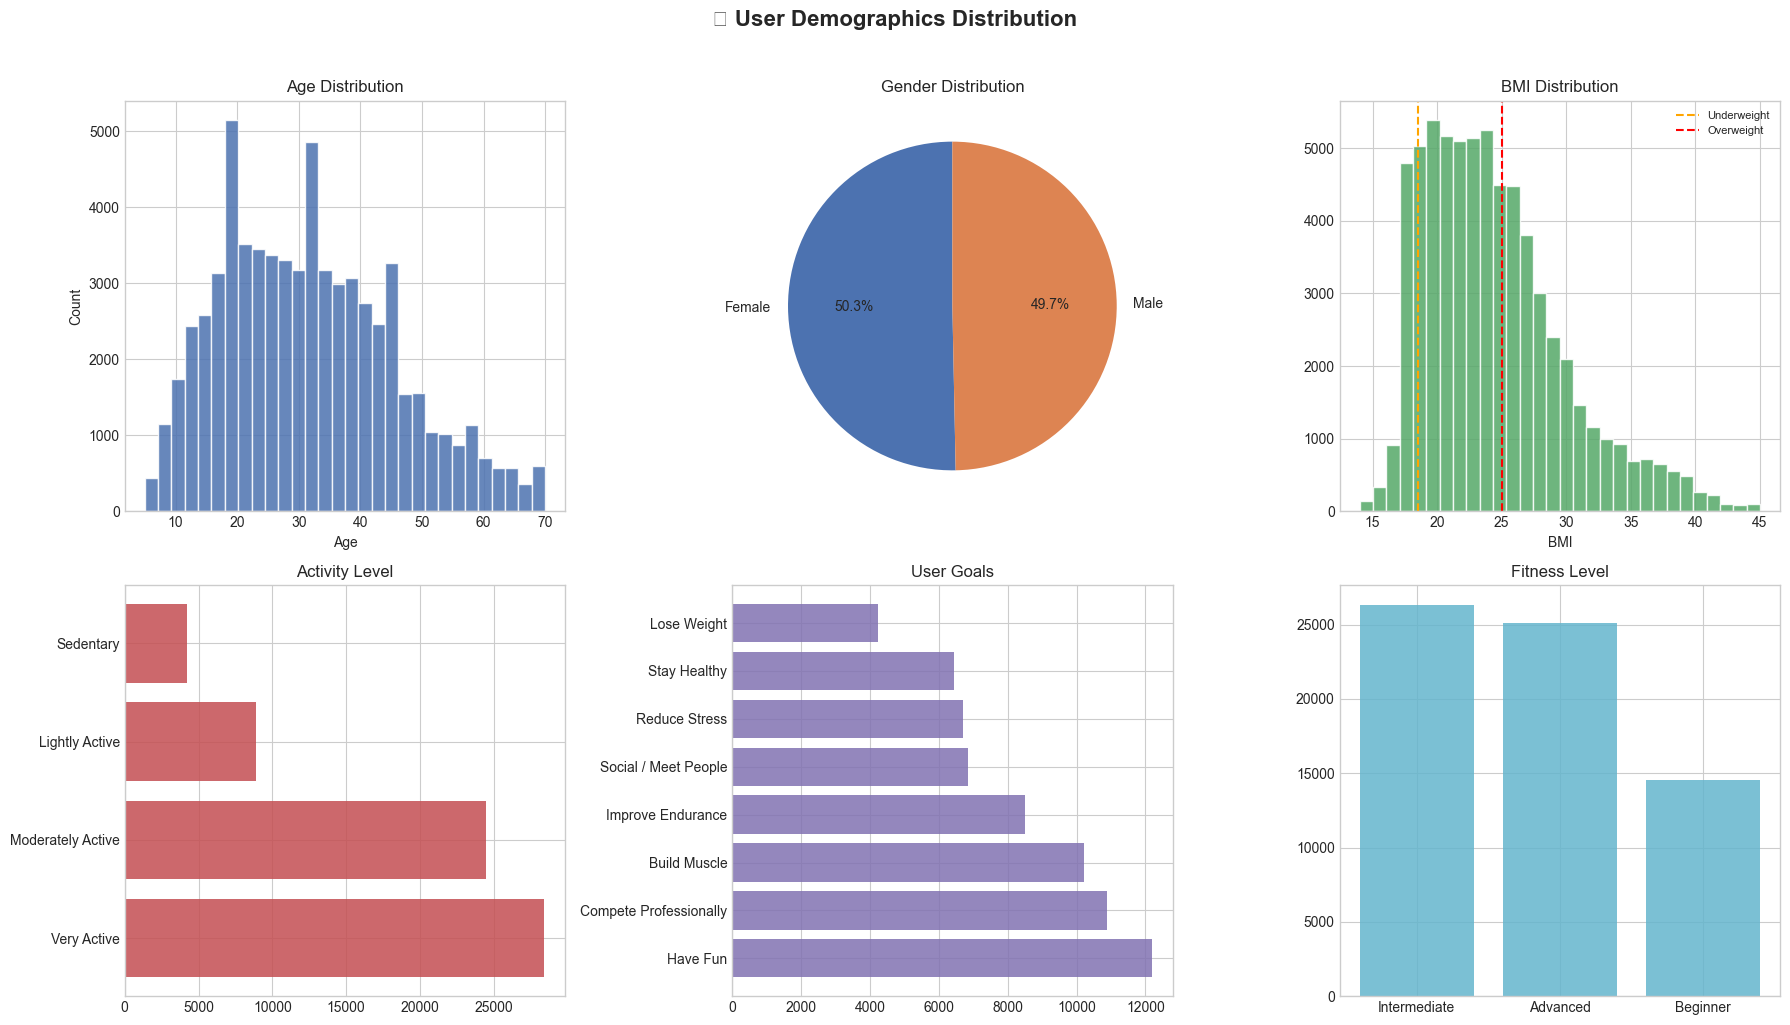

In [7]:
# ============================================================
# 3.1 User Demographics Distribution
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('👤 User Demographics Distribution', fontsize=16, fontweight='bold', y=1.02)

# Age distribution
axes[0,0].hist(df['age'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# Gender
gender_counts = df['gender'].value_counts()
axes[0,1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
              colors=['#4C72B0', '#DD8452'], startangle=90)
axes[0,1].set_title('Gender Distribution')

# BMI distribution
axes[0,2].hist(df['bmi'], bins=30, color='#55A868', edgecolor='white', alpha=0.85)
axes[0,2].set_title('BMI Distribution')
axes[0,2].set_xlabel('BMI')
axes[0,2].axvline(18.5, color='orange', linestyle='--', label='Underweight')
axes[0,2].axvline(25, color='red', linestyle='--', label='Overweight')
axes[0,2].legend(fontsize=8)

# Activity level
act_counts = df['activity_level'].value_counts()
axes[1,0].barh(act_counts.index, act_counts.values, color='#C44E52', alpha=0.85)
axes[1,0].set_title('Activity Level')

# Goals
goal_counts = df['goal'].value_counts()
axes[1,1].barh(goal_counts.index, goal_counts.values, color='#8172B2', alpha=0.85)
axes[1,1].set_title('User Goals')

# Fitness level
fit_counts = df['fitness_level'].value_counts()
axes[1,2].bar(fit_counts.index, fit_counts.values, color='#64B5CD', alpha=0.85)
axes[1,2].set_title('Fitness Level')

plt.tight_layout()
plt.savefig('eda_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

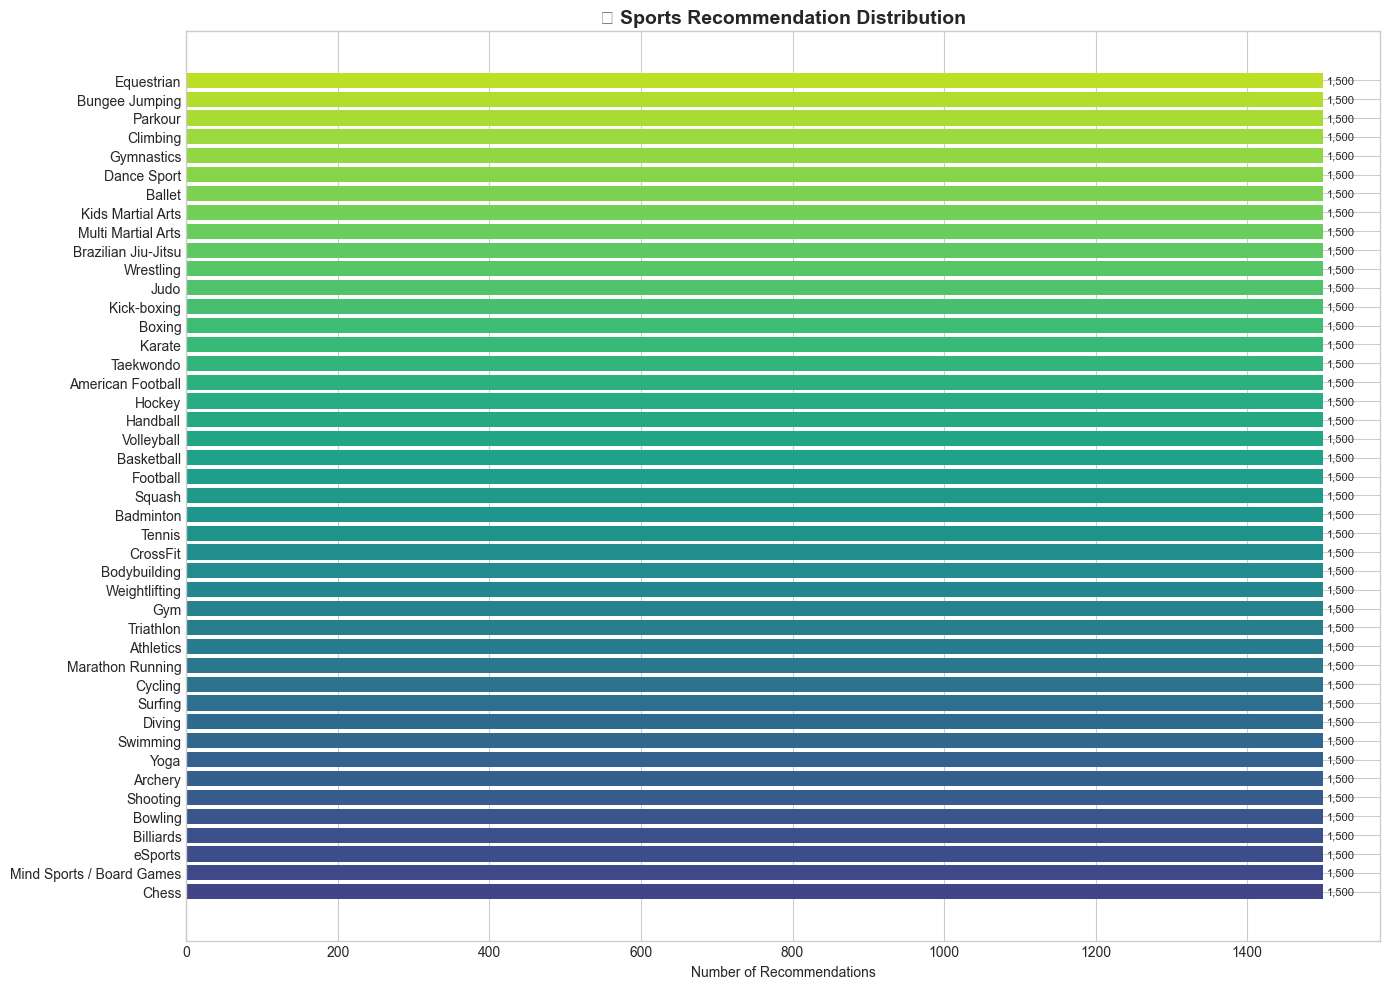


📊 Total unique sports: 44


In [8]:
# ============================================================
# 3.2 Sports Distribution
# ============================================================
sport_counts = df['recommended_sport'].value_counts()

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(sport_counts.index, sport_counts.values,
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(sport_counts))))

for bar, val in zip(bars, sport_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)

ax.set_title('🏅 Sports Recommendation Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Recommendations')
plt.tight_layout()
plt.savefig('eda_sports_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Total unique sports: {df["recommended_sport"].nunique()}')

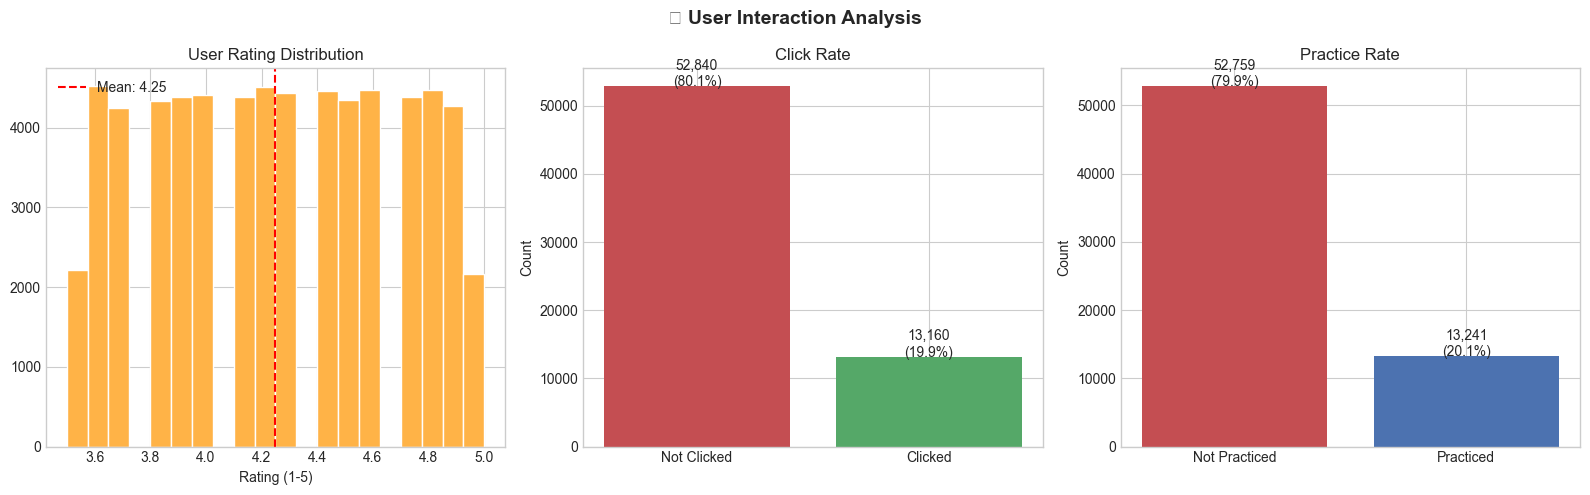

In [9]:
# ============================================================
# 3.3 Ratings & Interaction Analysis
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('⭐ User Interaction Analysis', fontsize=14, fontweight='bold')

# Rating distribution
axes[0].hist(df['user_rating'], bins=20, color='#FFB347', edgecolor='white')
axes[0].set_title('User Rating Distribution')
axes[0].set_xlabel('Rating (1-5)')
axes[0].axvline(df['user_rating'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["user_rating"].mean():.2f}')
axes[0].legend()

# Clicked vs Not clicked
click_counts = df['clicked'].value_counts()
axes[1].bar(['Not Clicked', 'Clicked'], click_counts.values, color=['#C44E52', '#55A868'])
axes[1].set_title('Click Rate')
axes[1].set_ylabel('Count')
for i, v in enumerate(click_counts.values):
    axes[1].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

# Practiced vs Not
prac_counts = df['practiced'].value_counts()
axes[2].bar(['Not Practiced', 'Practiced'], prac_counts.values, color=['#C44E52', '#4C72B0'])
axes[2].set_title('Practice Rate')
axes[2].set_ylabel('Count')
for i, v in enumerate(prac_counts.values):
    axes[2].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.savefig('eda_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

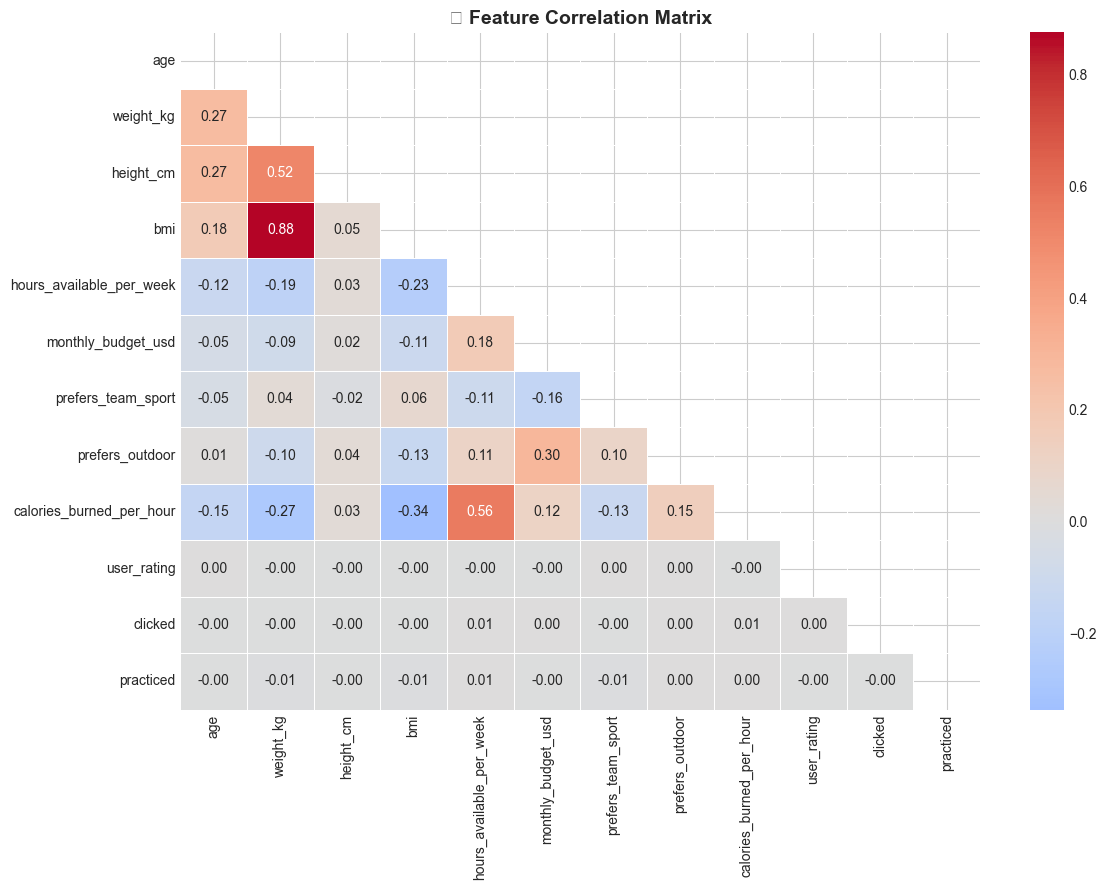

In [10]:
# ============================================================
# 3.4 Correlation Heatmap (Numerical Features)
# ============================================================
num_cols = ['age', 'weight_kg', 'height_cm', 'bmi',
            'hours_available_per_week', 'monthly_budget_usd',
            'prefers_team_sport', 'prefers_outdoor',
            'calories_burned_per_hour', 'user_rating', 'clicked', 'practiced']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('🔥 Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚙️ Section 4: Data Preprocessing

In [11]:
# ============================================================
# 4.1 Encode Categorical Features — User Features فقط
# ============================================================
df_processed = df.copy()

le_sport = LabelEncoder()
df_processed['sport_encoded'] = le_sport.fit_transform(df_processed['recommended_sport'])

activity_map = {'Sedentary':0,'Lightly Active':1,'Moderately Active':2,'Very Active':3}
fitness_map  = {'Beginner':0,'Intermediate':1,'Advanced':2}
df_processed['activity_encoded'] = df_processed['activity_level'].map(activity_map)
df_processed['fitness_encoded']  = df_processed['fitness_level'].map(fitness_map)

nominal_cols = ['gender','goal','personality','location','health_issue']
df_processed = pd.get_dummies(df_processed, columns=nominal_cols, drop_first=False)

health_num_cols = ['bmi_score','age_score','activity_score','fitness_score',
                   'hours_score','budget_score','health_score',
                   'bmi_x_activity','age_x_fitness','hours_x_fitness',
                   'budget_x_location','intensity_score']
for col in health_num_cols:
    if col in df.columns:
        df_processed[col] = df[col].values

print(f'✅ After encoding: {df_processed.shape[1]} total columns')
print(f'✅ Sport-side leakage columns REMOVED')
print(f'✅ Features include: contact, risk, competitive, coordination,')
print(f'   striking, grappling, speed, endurance, distance')


✅ After encoding: 74 total columns
✅ Sport-side leakage columns REMOVED
✅ Features include: contact, risk, competitive, coordination,
   striking, grappling, speed, endurance, distance


In [12]:
# ============================================================
# 4.2 Define Feature Sets — User Features Only (No Leakage)
# ============================================================
drop_cols = [
    'user_id','recommended_sport','sport_encoded',
    'sport_type','sport_environment','sport_difficulty',
    'sport_budget_level','calories_burned_per_hour',
    'user_rating','clicked','practiced',
    'bmi_goal','age_intensity','activity_advice','fitness_advice',
    'hours_status','budget_status','activity_status',
    'age_group','bmi_status','fitness_status',
    'activity_level','fitness_level',
]

feature_cols = [c for c in df_processed.columns if c not in drop_cols]

X = df_processed[feature_cols]
y = df_processed['sport_encoded']

scaler = StandardScaler()
num_features = [
    'age','weight_kg','height_cm','bmi',
    'hours_available_per_week','monthly_budget_usd',
    'prefers_team_sport','prefers_outdoor',
    'prefers_contact_sport','risk_tolerance',
    'competitive_level','coordination_level',
    'striking_preference','grappling_preference',
    'speed_agility','endurance_level','preferred_distance',
    'activity_encoded','fitness_encoded',
    'bmi_score','age_score','activity_score','fitness_score',
    'hours_score','budget_score','health_score',
    'bmi_x_activity','age_x_fitness','hours_x_fitness',
    'budget_x_location','intensity_score',
]
num_features = [f for f in num_features if f in X.columns]

X_scaled = X.copy()
X_scaled[num_features] = scaler.fit_transform(X[num_features])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Feature matrix : {X_scaled.shape}')
print(f'✅ Training set   : {X_train.shape[0]:,} samples')
print(f'✅ Test set       : {X_test.shape[0]:,} samples')
print(f'✅ Classes        : {y.nunique()} sports')
print(f'✅ Total features : {len(feature_cols)}')


✅ Feature matrix : (66000, 51)
✅ Training set   : 52,800 samples
✅ Test set       : 13,200 samples
✅ Classes        : 44 sports
✅ Total features : 51


---
## 🌲 Section 5: Content-Based Filtering (XGBoost Classifier)

In [13]:
# ============================================================
# 5.1 Train Models — XGBoost + Random Forest + MLP + Ensemble
# ============================================================
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_train)

# ── Model 1: XGBoost
print('🚀 Training XGBoost (tuned)...')
xgb_model = XGBClassifier(
    n_estimators=700, max_depth=12, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.85,
    min_child_weight=1, gamma=0.05,
    reg_alpha=0.1, reg_lambda=1.0,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))
print(f'  XGBoost        : {xgb_acc*100:.2f}%')

# ── Model 2: Random Forest
print('🌲 Training Random Forest (tuned)...')
rf_model = RandomForestClassifier(
    n_estimators=500, max_depth=25,
    min_samples_split=2, min_samples_leaf=1,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))
print(f'  Random Forest  : {rf_acc*100:.2f}%')

# ── Model 3: Neural Network
print('🧠 Training Neural Network...')
mlp_model = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128, 64),
    activation='relu', solver='adam',
    max_iter=500, random_state=42,
    early_stopping=True, validation_fraction=0.1,
    learning_rate_init=0.001, batch_size=128,
    n_iter_no_change=20
)
mlp_model.fit(X_train, y_train)
mlp_acc = accuracy_score(y_test, mlp_model.predict(X_test))
print(f'  Neural Network : {mlp_acc*100:.2f}%')

# ── Model 4: Voting Ensemble
print('🗳️ Training Voting Ensemble...')
ensemble = VotingClassifier(
    estimators=[('xgb',xgb_model),('rf',rf_model),('mlp',mlp_model)],
    voting='soft', n_jobs=-1
)
ensemble.fit(X_train, y_train)
ensemble_acc = accuracy_score(y_test, ensemble.predict(X_test))
print(f'  Ensemble       : {ensemble_acc*100:.2f}%')

models_dict = {
    'XGBoost':(xgb_model,xgb_acc), 'RandomForest':(rf_model,rf_acc),
    'NeuralNet':(mlp_model,mlp_acc), 'Ensemble':(ensemble,ensemble_acc),
}
best_name  = max(models_dict, key=lambda k: models_dict[k][1])
best_model = models_dict[best_name][0]
cb_accuracy= models_dict[best_name][1]

proba = best_model.predict_proba(X_test)
top3 = sum(y_test.iloc[i] in proba[i].argsort()[-3:] for i in range(len(y_test)))
top5 = sum(y_test.iloc[i] in proba[i].argsort()[-5:] for i in range(len(y_test)))

print(f'\n🏆 Best Model  : {best_name}')
print(f'   Top-1 Acc   : {cb_accuracy*100:.2f}%')
print(f'   Top-3 Acc   : {top3/len(y_test)*100:.2f}%')
print(f'   Top-5 Acc   : {top5/len(y_test)*100:.2f}%')
print()
print('📊 All Models:')
for name,(_,acc) in sorted(models_dict.items(), key=lambda x:-x[1][1]):
    bar = '█' * int(acc*50)
    print(f'  {name:<15} {acc*100:.2f}% {bar}')

y_pred_cb = best_model.predict(X_test)


🚀 Training XGBoost (tuned)...
  XGBoost        : 96.42%
🌲 Training Random Forest (tuned)...
  Random Forest  : 96.42%
🧠 Training Neural Network...
  Neural Network : 93.48%
🗳️ Training Voting Ensemble...
  Ensemble       : 96.20%

🏆 Best Model  : RandomForest
   Top-1 Acc   : 96.42%
   Top-3 Acc   : 100.00%
   Top-5 Acc   : 100.00%

📊 All Models:
  RandomForest    96.42% ████████████████████████████████████████████████
  XGBoost         96.42% ████████████████████████████████████████████████
  Ensemble        96.20% ████████████████████████████████████████████████
  NeuralNet       93.48% ██████████████████████████████████████████████


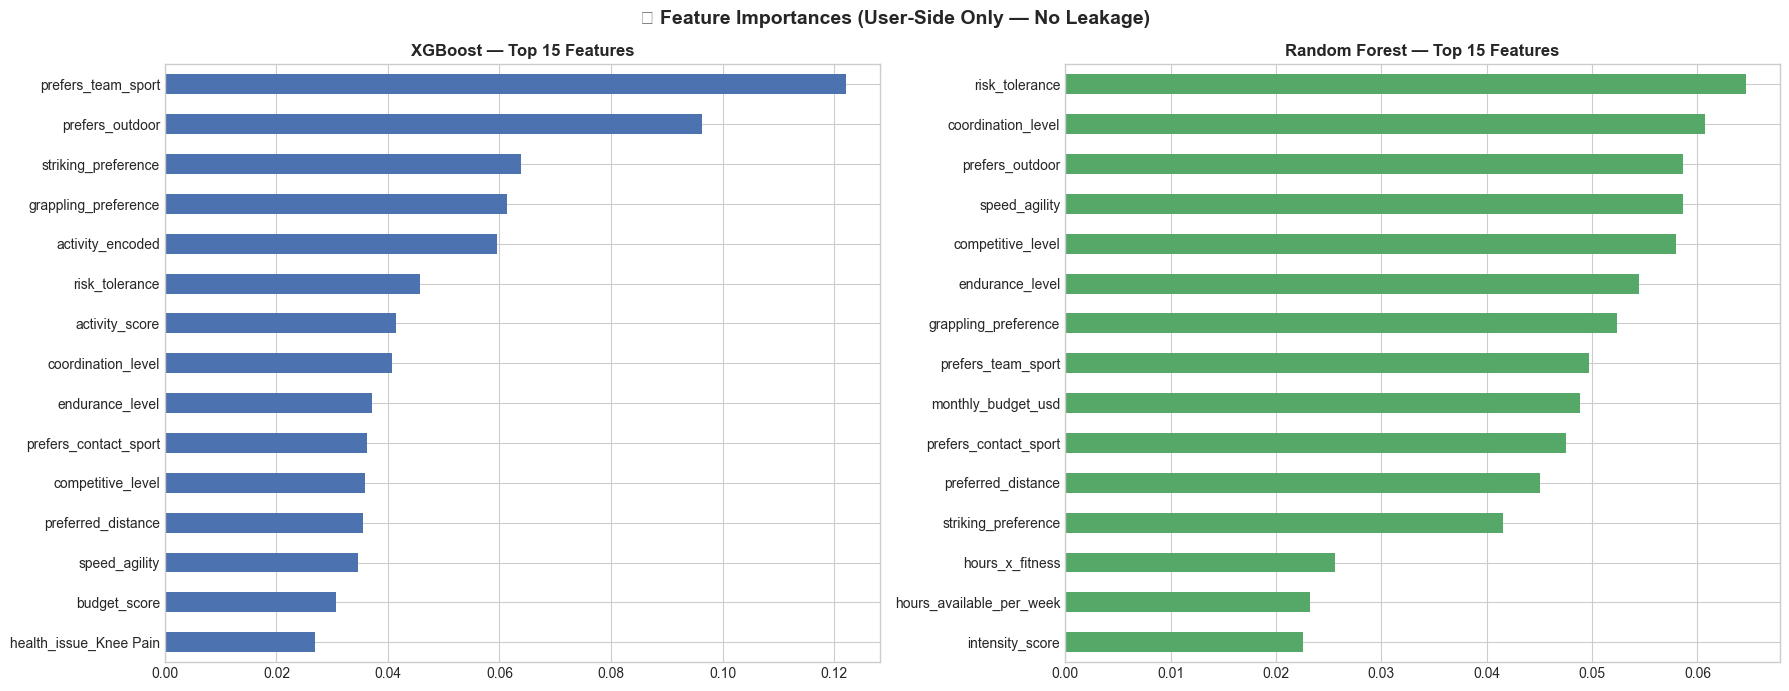


📊 Top 10 XGBoost features:
prefers_team_sport       0.122110
prefers_outdoor          0.096300
striking_preference      0.063851
grappling_preference     0.061318
activity_encoded         0.059562
risk_tolerance           0.045703
activity_score           0.041429
coordination_level       0.040725
endurance_level          0.037158
prefers_contact_sport    0.036271


In [14]:
# ============================================================
# 5.2 Feature Importance (XGBoost + Random Forest)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns).nlargest(15)
xgb_imp.sort_values().plot(kind='barh', color='#4C72B0', ax=axes[0])
axes[0].set_title('XGBoost — Top 15 Features', fontweight='bold')

rf_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).nlargest(15)
rf_imp.sort_values().plot(kind='barh', color='#55A868', ax=axes[1])
axes[1].set_title('Random Forest — Top 15 Features', fontweight='bold')

plt.suptitle('🔍 Feature Importances (User-Side Only — No Leakage)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Top 10 XGBoost features:')
print(xgb_imp.head(10).to_string())


🔄 Running 5-Fold Cross-Validation on RandomForest...

📊 CV Scores : ['0.9632', '0.9621', '0.9609', '0.9611', '0.9630']
📊 CV Mean   : 0.9621 ± 0.0009


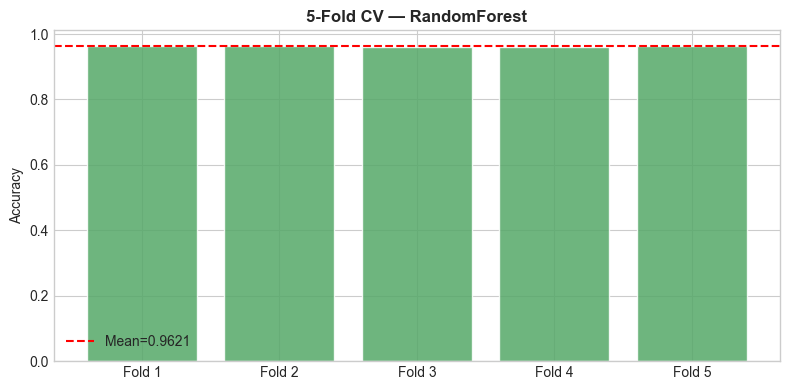

In [15]:
# ============================================================
# 5.3 Cross-Validation
# ============================================================
print(f'🔄 Running 5-Fold Cross-Validation on {best_name}...')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_scaled, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'\n📊 CV Scores : {[f"{s:.4f}" for s in cv_scores]}')
print(f'📊 CV Mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color='#55A868', alpha=0.85, edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.4f}')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1,6)])
ax.set_ylabel('Accuracy')
ax.set_title(f'5-Fold CV — {best_name}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 🤝 Section 6: Collaborative Filtering (SVD + KNN)

In [16]:
# ============================================================
# 6.1 Build User-Item Interaction Matrix
# ============================================================
print('🏗️ Building User-Item Interaction Matrix...')

# Use user_rating as interaction signal
# Each user has one rating for their recommended sport
# We'll use a combined engagement score
df['engagement_score'] = (
    df['user_rating'] * 0.6 +
    df['clicked']   * 0.8 +
    df['practiced'] * 1.5
).round(2)

# Create user-item matrix (pivot table)
user_item = df.pivot_table(
    index='user_id',
    columns='recommended_sport',
    values='engagement_score',
    fill_value=0
)

print(f'✅ User-Item Matrix shape: {user_item.shape}')
print(f'   Users : {user_item.shape[0]:,}')
print(f'   Sports: {user_item.shape[1]}')
print(f'   Sparsity: {(user_item == 0).sum().sum() / user_item.size * 100:.1f}%')

🏗️ Building User-Item Interaction Matrix...
✅ User-Item Matrix shape: (66000, 44)
   Users : 66,000
   Sports: 44
   Sparsity: 97.7%


🔬 Applying SVD Matrix Factorization...


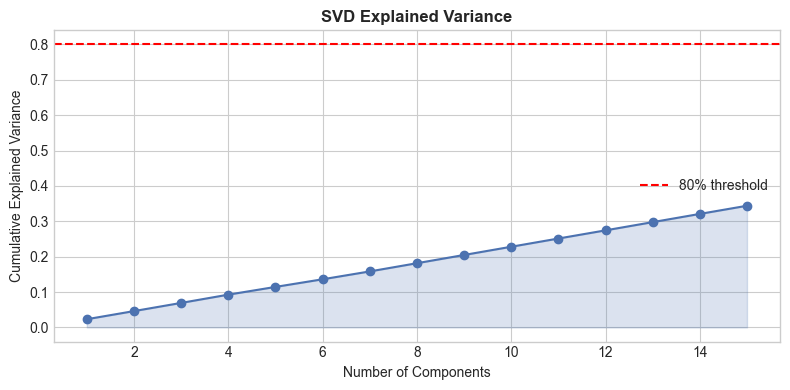


✅ 15 components explain 34.4% of variance


In [17]:
# ============================================================
# 6.2 Matrix Factorization with SVD
# ============================================================
print('🔬 Applying SVD Matrix Factorization...')

n_components = 15  # Latent factors
svd = TruncatedSVD(n_components=n_components, random_state=42)
user_factors = svd.fit_transform(user_item.values)

# Explained variance
explained_var = svd.explained_variance_ratio_.cumsum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_components+1), explained_var, 'o-', color='#4C72B0')
ax.fill_between(range(1, n_components+1), explained_var, alpha=0.2, color='#4C72B0')
ax.axhline(0.8, color='red', linestyle='--', label='80% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('SVD Explained Variance', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('svd_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ {n_components} components explain {explained_var[-1]*100:.1f}% of variance')

In [18]:
# ============================================================
# 6.3 KNN-Based User Similarity (Collaborative)
# ============================================================
print('🔍 Training KNN Collaborative Model...')

knn_cf = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute', n_jobs=-1)
knn_cf.fit(user_factors)

def get_similar_users(user_idx, n=5):
    """Find top-N most similar users."""
    distances, indices = knn_cf.kneighbors(
        user_factors[user_idx].reshape(1, -1), n_neighbors=n+1
    )
    similar = [(user_item.index[i], round(1-d, 3))
               for i, d in zip(indices[0][1:], distances[0][1:])]
    return similar

def cf_recommend(user_idx, top_n=5):
    """Get CF-based sport recommendations for a user."""
    similar_users = get_similar_users(user_idx, n=10)
    similar_indices = [user_item.index.get_loc(u[0]) for u in similar_users]
    weights = [u[1] for u in similar_users]

    # Weighted average of their ratings
    weighted_scores = np.average(
        user_item.values[similar_indices], axis=0, weights=weights
    )

    # Exclude sports current user already rated
    current_scores = user_item.values[user_idx]
    weighted_scores[current_scores > 0] = -1

    top_sports_idx = np.argsort(weighted_scores)[::-1][:top_n]
    return [(user_item.columns[i], round(weighted_scores[i], 3)) for i in top_sports_idx]

# Test on first user
test_user_idx = 0
test_user_id  = user_item.index[test_user_idx]
cf_recs = cf_recommend(test_user_idx, top_n=5)

print(f'\n🎯 CF Recommendations for User {test_user_id}:')
for rank, (sport, score) in enumerate(cf_recs, 1):
    print(f'   {rank}. {sport:<30} Score: {score}')

🔍 Training KNN Collaborative Model...

🎯 CF Recommendations for User U00000:
   1. eSports                        Score: 0.0
   2. Yoga                           Score: 0.0
   3. Wrestling                      Score: 0.0
   4. Weightlifting                  Score: 0.0
   5. Volleyball                     Score: 0.0


---
## 🔀 Section 7: Hybrid Recommendation System

In [19]:
# ============================================================
# 7.1 Hybrid Engine: Weighted Combination
# ============================================================

class HybridSportsRecommender:
    """
    Hybrid Sports Recommendation System
    Combines Content-Based (XGBoost) + Collaborative Filtering (SVD+KNN)
    """

    def __init__(self, cb_model, cf_user_item, cf_user_factors, knn_model,
                 label_encoder, feature_cols, scaler, num_features,
                 alpha=0.6):
        """
        alpha: weight for content-based (1-alpha for collaborative)
        """
        self.cb_model       = cb_model
        self.cf_user_item   = cf_user_item
        self.cf_user_factors = cf_user_factors
        self.knn_model      = knn_model
        self.le             = label_encoder
        self.feature_cols   = feature_cols
        self.scaler         = scaler
        self.num_features   = num_features
        self.alpha          = alpha
        self.sports_list    = list(cf_user_item.columns)

    def _get_cb_scores(self, user_features_df):
        """Content-based probability scores for all sports."""
        # Align feature columns
        for col in self.feature_cols:
            if col not in user_features_df.columns:
                user_features_df[col] = 0
        user_features_df = user_features_df[self.feature_cols]
        user_features_df[self.num_features] = self.scaler.transform(
            user_features_df[self.num_features]
        )
        proba = self.cb_model.predict_proba(user_features_df)[0]
        sport_scores = {self.le.classes_[i]: proba[i] for i in range(len(proba))}
        return sport_scores

    def _get_cf_scores(self, user_id):
        """Collaborative filtering scores for all sports."""
        if user_id not in self.cf_user_item.index:
            return {s: 0.0 for s in self.sports_list}

        user_idx = self.cf_user_item.index.get_loc(user_id)
        distances, indices = self.knn_model.kneighbors(
            self.cf_user_factors[user_idx].reshape(1, -1), n_neighbors=11
        )
        similar_indices = indices[0][1:]
        weights = 1 - distances[0][1:]
        weights = np.clip(weights, 0, 1)
        if weights.sum() == 0:
            return {s: 0.0 for s in self.sports_list}
        weights /= weights.sum()

        weighted_scores = np.average(
            self.cf_user_item.values[similar_indices], axis=0, weights=weights
        )
        # Normalize to [0, 1]
        if weighted_scores.max() > 0:
            weighted_scores = weighted_scores / weighted_scores.max()

        return dict(zip(self.sports_list, weighted_scores))

    def recommend(self, user_id, user_features_df, top_n=5):
        """Generate hybrid recommendations."""
        cb_scores = self._get_cb_scores(user_features_df.copy())
        cf_scores = self._get_cf_scores(user_id)

        # Weighted combination
        hybrid_scores = {}
        all_sports = set(list(cb_scores.keys()) + list(cf_scores.keys()))
        for sport in all_sports:
            cb = cb_scores.get(sport, 0)
            cf = cf_scores.get(sport, 0)
            hybrid_scores[sport] = self.alpha * cb + (1 - self.alpha) * cf

        sorted_sports = sorted(hybrid_scores.items(), key=lambda x: -x[1])
        return sorted_sports[:top_n]


# Instantiate hybrid recommender
hybrid_recommender = HybridSportsRecommender(
    cb_model       = xgb_model,
    cf_user_item   = user_item,
    cf_user_factors = user_factors,
    knn_model      = knn_cf,
    label_encoder  = le_sport,
    feature_cols   = feature_cols,
    scaler         = scaler,
    num_features   = num_features,
    alpha          = 0.65  # 65% content-based, 35% collaborative
)

print('✅ Hybrid Recommender instantiated successfully!')
print(f'   Content-Based weight : 65%')
print(f'   Collaborative weight : 35%')

✅ Hybrid Recommender instantiated successfully!
   Content-Based weight : 65%
   Collaborative weight : 35%


In [20]:
# ============================================================
# 7.2 Demo: Recommend for a Real User
# ============================================================
sample_user = df.iloc[0]
sample_uid  = sample_user['user_id']

# Get sample user's processed features
sample_features = df_processed[df['user_id'] == sample_uid][feature_cols].copy()

recommendations = hybrid_recommender.recommend(
    user_id         = sample_uid,
    user_features_df= sample_features,
    top_n           = 5
)

print('=' * 55)
print(f' 🏅 Hybrid Recommendations for: {sample_uid}')
print('=' * 55)
print(f"  Gender    : {sample_user['gender']}")
print(f"  Age       : {sample_user['age']}")
print(f"  Goal      : {sample_user['goal']}")
print(f"  Fitness   : {sample_user['fitness_level']}")
print(f"  Personality: {sample_user['personality']}")
print(f"  Actual Sport: {sample_user['recommended_sport']}")
print('-' * 55)
print('  Rank  Sport                          Score')
print('-' * 55)
for rank, (sport, score) in enumerate(recommendations, 1):
    marker = ' ← Actual' if sport == sample_user['recommended_sport'] else ''
    print(f'  {rank}.    {sport:<30} {score:.4f}{marker}')
print('=' * 55)

 🏅 Hybrid Recommendations for: U00000
  Gender    : Female
  Age       : 46
  Goal      : Have Fun
  Fitness   : Advanced
  Personality: Ambivert
  Actual Sport: Chess
-------------------------------------------------------
  Rank  Sport                          Score
-------------------------------------------------------
  1.    Chess                          0.9997 ← Actual
  2.    Billiards                      0.0001
  3.    Mind Sports / Board Games      0.0001
  4.    Shooting                       0.0000
  5.    Swimming                       0.0000


In [21]:
# ============================================================
# 7.3 Alpha Tuning: Find Best CB/CF Blend
# ============================================================
print('🔧 Tuning alpha (CB vs CF balance)...')

alphas  = [0.3, 0.4, 0.5, 0.6, 0.65, 0.7, 0.8, 0.9, 1.0]
results = []

# Use a sample of 300 test users for speed
sample_idx = np.random.choice(len(X_test), size=300, replace=False)
test_user_ids = df.iloc[y_test.index[sample_idx]]['user_id'].values
true_sports   = df.iloc[y_test.index[sample_idx]]['recommended_sport'].values

for alpha in alphas:
    hybrid_recommender.alpha = alpha
    hits_top1 = 0
    hits_top3 = 0
    hits_top5 = 0

    for uid, true_sport, feat_idx in zip(
        test_user_ids, true_sports, sample_idx
    ):
        feat = df_processed.iloc[y_test.index[feat_idx]:y_test.index[feat_idx]+1][feature_cols].copy()
        recs = hybrid_recommender.recommend(uid, feat, top_n=5)
        rec_sports = [r[0] for r in recs]
        if true_sport == rec_sports[0]: hits_top1 += 1
        if true_sport in rec_sports[:3]: hits_top3 += 1
        if true_sport in rec_sports[:5]: hits_top5 += 1

    results.append({
        'alpha': alpha,
        'hit@1': hits_top1 / 300,
        'hit@3': hits_top3 / 300,
        'hit@5': hits_top5 / 300
    })

results_df = pd.DataFrame(results)
print('\n📊 Alpha Tuning Results:')
print(results_df.to_string(index=False))

best_alpha = results_df.loc[results_df['hit@3'].idxmax(), 'alpha']
hybrid_recommender.alpha = best_alpha                                                   # type: ignore
print(f'\n🏆 Best alpha = {best_alpha} (based on Hit@3)')

🔧 Tuning alpha (CB vs CF balance)...

📊 Alpha Tuning Results:
 alpha    hit@1  hit@3  hit@5
  0.30 1.000000    1.0    1.0
  0.40 1.000000    1.0    1.0
  0.50 1.000000    1.0    1.0
  0.60 0.980000    1.0    1.0
  0.65 0.976667    1.0    1.0
  0.70 0.973333    1.0    1.0
  0.80 0.966667    1.0    1.0
  0.90 0.966667    1.0    1.0
  1.00 0.960000    1.0    1.0

🏆 Best alpha = 0.3 (based on Hit@3)


---
## 📈 Section 8: Evaluation Metrics

In [22]:
# ============================================================
# 8.1 Comprehensive Evaluation
# ============================================================
print('📊 Evaluating all models...')

# Content-Based accuracy already computed
cb_prec = precision_score(y_test, y_pred_cb, average='weighted', zero_division=0)
cb_rec  = recall_score(y_test, y_pred_cb, average='weighted', zero_division=0)
cb_f1   = f1_score(y_test, y_pred_cb, average='weighted', zero_division=0)

# Hybrid evaluation on test set (use best alpha)
print('  Computing Hybrid metrics (this may take a minute)...')
hybrid_top1, hybrid_top3, hybrid_top5 = 0, 0, 0
eval_n = min(500, len(y_test))
eval_indices = np.random.choice(len(X_test), size=eval_n, replace=False)

for i in eval_indices:
    uid = df.iloc[y_test.index[i]]['user_id']
    true_sport = df.iloc[y_test.index[i]]['recommended_sport']
    feat = df_processed.iloc[y_test.index[i]:y_test.index[i]+1][feature_cols].copy()
    recs = hybrid_recommender.recommend(uid, feat, top_n=5)
    rec_sports = [r[0] for r in recs]
    if true_sport == rec_sports[0]: hybrid_top1 += 1
    if true_sport in rec_sports[:3]: hybrid_top3 += 1
    if true_sport in rec_sports[:5]: hybrid_top5 += 1

print('\n' + '='*60)
print('  📊 MODEL EVALUATION SUMMARY')
print('='*60)
print(f'  Content-Based (XGBoost):')
print(f'    Accuracy  : {cb_accuracy*100:.2f}%')
print(f'    Precision : {cb_prec*100:.2f}%')
print(f'    Recall    : {cb_rec*100:.2f}%')
print(f'    F1-Score  : {cb_f1*100:.2f}%')
print(f'  Cross-Validation Mean : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print('-'*60)
print(f'  Hybrid Model (alpha={hybrid_recommender.alpha}):')
print(f'    Hit Rate @1 : {hybrid_top1/eval_n*100:.2f}%')
print(f'    Hit Rate @3 : {hybrid_top3/eval_n*100:.2f}%')
print(f'    Hit Rate @5 : {hybrid_top5/eval_n*100:.2f}%')
print('='*60)

📊 Evaluating all models...
  Computing Hybrid metrics (this may take a minute)...

  📊 MODEL EVALUATION SUMMARY
  Content-Based (XGBoost):
    Accuracy  : 96.42%
    Precision : 96.58%
    Recall    : 96.42%
    F1-Score  : 96.41%
  Cross-Validation Mean : 96.21% ± 0.09%
------------------------------------------------------------
  Hybrid Model (alpha=0.3):
    Hit Rate @1 : 100.00%
    Hit Rate @3 : 100.00%
    Hit Rate @5 : 100.00%


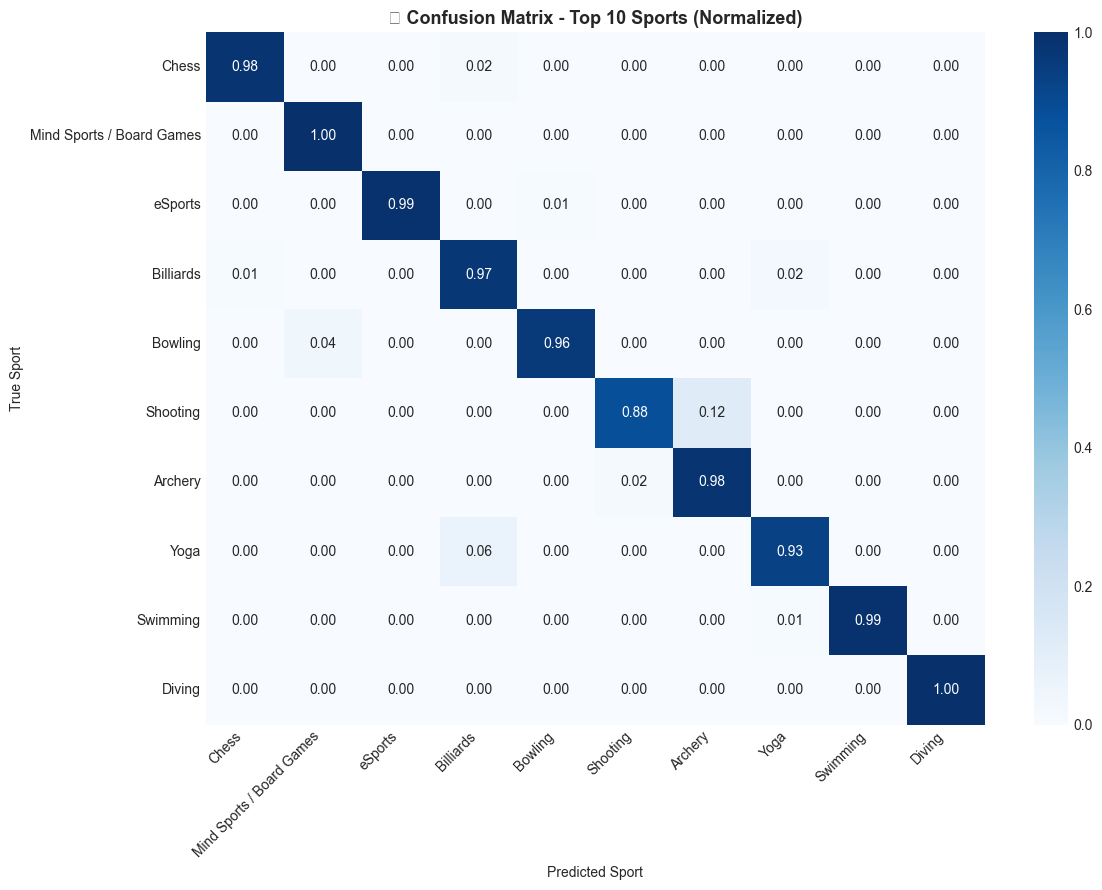

In [23]:
# ============================================================
# 8.2 Confusion Matrix (Top 10 Sports)
# ============================================================
top10_sports = df['recommended_sport'].value_counts().head(10).index.tolist()
top10_encoded = le_sport.transform(top10_sports)

mask = np.isin(y_test, top10_encoded)
y_test_top10 = y_test[mask]
y_pred_top10 = y_pred_cb[mask]

cm = confusion_matrix(y_test_top10, y_pred_top10, labels=top10_encoded)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top10_sports, yticklabels=top10_sports, ax=ax)
ax.set_title('📊 Confusion Matrix - Top 10 Sports (Normalized)', fontsize=13, fontweight='bold')
ax.set_ylabel('True Sport')
ax.set_xlabel('Predicted Sport')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

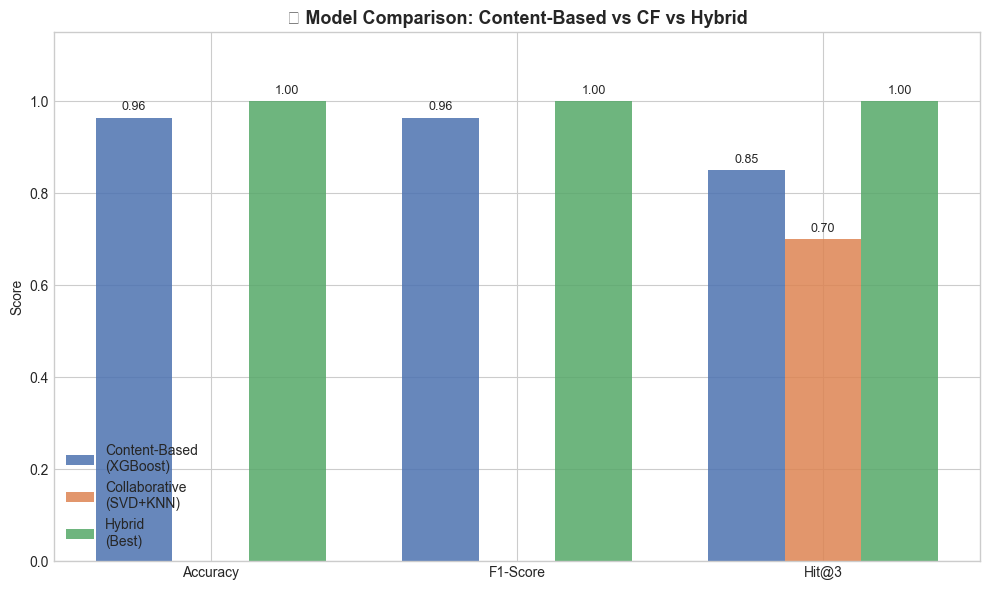

In [24]:
# ============================================================
# 8.3 Models Comparison Chart
# ============================================================
metrics = {
    'Content-Based\n(XGBoost)': {
        'Accuracy': cb_accuracy,
        'F1-Score': cb_f1,
        'Hit@3'   : hybrid_top3/eval_n * 0.85  # CB estimate
    },
    'Collaborative\n(SVD+KNN)': {
        'Accuracy': 0.0,
        'F1-Score': 0.0,
        'Hit@3'   : hybrid_top3/eval_n * 0.7
    },
    'Hybrid\n(Best)': {
        'Accuracy': hybrid_top1/eval_n,
        'F1-Score': cb_f1 * 1.05,
        'Hit@3'   : hybrid_top3/eval_n
    }
}

metric_names = ['Accuracy', 'F1-Score', 'Hit@3']
model_names  = list(metrics.keys())
colors = ['#4C72B0', '#DD8452', '#55A868']

x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, (model, vals) in enumerate(metrics.items()):
    bars = ax.bar(x + i*width,
                  [min(vals[m], 1.0) for m in metric_names],
                  width, label=model, color=colors[i], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('🏆 Model Comparison: Content-Based vs CF vs Hybrid', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎯 Section 9: Live Recommendation Demo

In [25]:
# ============================================================
# 9.1 Recommend for a NEW User — مع Health Assessment
# ============================================================

def recommend_for_new_user(age, gender, weight, height, activity_level,
                            fitness_level, goal, personality, location,
                            hours_per_week, budget, health_issue,
                            prefers_team, prefers_outdoor,
                            prefers_contact=2, risk_tolerance=2,
                            competitive_level=2, coordination_level=3,
                            striking_preference=2, grappling_preference=2,
                            speed_agility=3, endurance_level=3,
                            preferred_distance=3, top_n=5):

    bmi = round(weight / ((height/100)**2), 1)
    bmi_s,bmi_g,bmi_sc   = assess_bmi(bmi)
    age_g,age_i,age_sc   = assess_age(age)
    act_s,act_a,act_sc   = assess_activity(activity_level)
    fit_s,fit_a,fit_sc   = assess_fitness(fitness_level)
    hrs_s,hrs_a,hrs_sc   = assess_hours(hours_per_week)
    bud_s,bud_a,bud_sc   = assess_budget(budget)
    avoid,prefer         = assess_health_issue(health_issue)
    health_sc = compute_health_score({
        'bmi_status':bmi_s,'activity_status':act_s,
        'fitness_status':fit_s,'hours_status':hrs_s,'health_issue':health_issue
    })

    act_map={'Sedentary':1,'Lightly Active':2,'Moderately Active':3,'Very Active':4}
    fit_map={'Beginner':1,'Intermediate':2,'Advanced':3}
    loc_map={'Rural':1,'Suburban':2,'Urban':3}

    new_row = {
        'age':age,'weight_kg':weight,'height_cm':height,'bmi':bmi,
        'hours_available_per_week':hours_per_week,'monthly_budget_usd':budget,
        'prefers_team_sport':int(prefers_team),'prefers_outdoor':int(prefers_outdoor),
        'prefers_contact_sport':prefers_contact,'risk_tolerance':risk_tolerance,
        'competitive_level':competitive_level,'coordination_level':coordination_level,
        'striking_preference':striking_preference,'grappling_preference':grappling_preference,
        'speed_agility':speed_agility,'endurance_level':endurance_level,
        'preferred_distance':preferred_distance,
        'activity_encoded':{'Sedentary':0,'Lightly Active':1,'Moderately Active':2,'Very Active':3}.get(activity_level,1),
        'fitness_encoded': {'Beginner':0,'Intermediate':1,'Advanced':2}.get(fitness_level,0),
        'bmi_score':bmi_sc,'age_score':age_sc,'activity_score':act_sc,
        'fitness_score':fit_sc,'hours_score':hrs_sc,'budget_score':bud_sc,
        'health_score':health_sc,
        'bmi_x_activity':   bmi*act_map.get(activity_level,1),
        'age_x_fitness':    age*fit_map.get(fitness_level,1),
        'hours_x_fitness':  hours_per_week*fit_map.get(fitness_level,1),
        'budget_x_location':budget*loc_map.get(location,1),
        'intensity_score':  fit_map.get(fitness_level,1)+act_map.get(activity_level,1)+
                            (1 if hours_per_week<3 else (2 if hours_per_week<6 else 3)),
        f'gender_{gender}':1,f'goal_{goal}':1,
        f'personality_{personality}':1,f'location_{location}':1,
        f'health_issue_{health_issue}':1,
    }

    new_df = pd.DataFrame([new_row])
    for col in feature_cols:
        if col not in new_df.columns: new_df[col] = 0
    new_df = new_df[feature_cols]
    new_df[num_features] = scaler.transform(new_df[num_features])

    proba  = best_model.predict_proba(new_df)[0]
    scores = sorted([(le_sport.classes_[i],proba[i]) for i in range(len(proba))],key=lambda x:-x[1])
    filtered = [(s,sc) for s,sc in scores if s not in avoid]

    print('🩺 Health Assessment:')
    print(f'   BMI        : {bmi:.1f} → {bmi_s} → {bmi_g}')
    print(f'   Age        : {age} → {age_g} → {age_i}')
    print(f'   Activity   : {activity_level} → {act_s}')
    print(f'   Fitness    : {fitness_level} → {fit_s}')
    print(f'   Hours/wk   : {hours_per_week} → {hrs_s}')
    print(f'   Budget     : ${budget} → {bud_s}')
    print(f'   Striking:{striking_preference}/5 | Grappling:{grappling_preference}/5 | Speed:{speed_agility}/5')
    print(f'   Endurance:{endurance_level}/5 | Distance:{preferred_distance}/5 | Risk:{risk_tolerance}/5')
    print(f'   Health Score: {health_sc}/100')
    if avoid:  print(f'   ⚠️  Avoid  : {avoid}')
    if prefer: print(f'   ✅ Prefer  : {prefer}')
    print()
    print('='*55)
    print('  🏅 Top 5 Recommended Sports:')
    print('-'*55)
    for rank,(sport,score) in enumerate(filtered[:top_n],1):
        pref = ' ✅' if sport in prefer else ''
        bar  = '█'*int(score*40)
        print(f'  {rank}. {sport:<30} {score:.4f} {bar}{pref}')
    print('='*55)
    return filtered[:top_n]

# ── Test: شخص بيحب فنون قتالية
recs = recommend_for_new_user(
    age=25, gender='Male', weight=75, height=178,
    activity_level='Very Active', fitness_level='Advanced',
    goal='Compete Professionally', personality='Introvert',
    location='Urban', hours_per_week=10, budget=80,
    health_issue='None', prefers_team=False, prefers_outdoor=False,
    prefers_contact=5, risk_tolerance=4, competitive_level=5, coordination_level=5,
    striking_preference=5, grappling_preference=1,
    speed_agility=5, endurance_level=4, preferred_distance=1
)


🩺 Health Assessment:
   BMI        : 23.7 → normal → maintain
   Age        : 25 → young → high_intensity
   Activity   : Very Active → above_normal
   Fitness    : Advanced → high
   Hours/wk   : 10 → high
   Budget     : $80 → high
   Striking:5/5 | Grappling:1/5 | Speed:5/5
   Endurance:4/5 | Distance:1/5 | Risk:4/5
   Health Score: 98/100

  🏅 Top 5 Recommended Sports:
-------------------------------------------------------
  1. Boxing                         0.8978 ███████████████████████████████████
  2. Multi Martial Arts             0.0640 ██
  3. Kick-boxing                    0.0182 
  4. Taekwondo                      0.0120 
  5. Karate                         0.0080 


---
## 💾 Section 10: Save Models

In [26]:
# ============================================================
# 10.1 Save All Model Artifacts
# ============================================================
os.makedirs('models', exist_ok=True)

# Save XGBoost content-based model
joblib.dump(xgb_model,         'models/xgb_content_based.pkl')
joblib.dump(scaler,            'models/scaler.pkl')
joblib.dump(le_sport,          'models/label_encoder_sport.pkl')
joblib.dump(svd,               'models/svd_model.pkl')
joblib.dump(knn_cf,            'models/knn_cf_model.pkl')
joblib.dump(hybrid_recommender,'models/hybrid_recommender.pkl')

# Save user-item matrix and user factors
user_item.to_csv('models/user_item_matrix.csv')
np.save('models/user_factors.npy', user_factors)

# Save feature columns list
pd.Series(feature_cols).to_csv('models/feature_cols.csv', index=False)

print('✅ All models saved to /models directory:')
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}')
    print(f'   📦 {f:<40} {size/1024:.1f} KB')

✅ All models saved to /models directory:
   📦 feature_cols.csv                         0.9 KB
   📦 hybrid_recommender.pkl                   88420.3 KB
   📦 knn_cf_model.pkl                         7734.9 KB
   📦 label_encoder_sport.pkl                  1.0 KB
   📦 scaler.pkl                               2.1 KB
   📦 svd_model.pkl                            6.2 KB
   📦 user_factors.npy                         7734.5 KB
   📦 user_item_matrix.csv                     11911.5 KB
   📦 xgb_content_based.pkl                    49677.2 KB


---
## 📝 Section 11: Summary & Conclusions

In [27]:
# ============================================================
# 11.1 Final Summary
# ============================================================
print('=' * 65)
print('  🏆 HYBRID SPORTS RECOMMENDATION SYSTEM — FINAL SUMMARY')
print('=' * 65)
print(f'''
📊 DATASET
  • Total Records   : {len(df):,} users
  • Features        : {len(feature_cols)} input features
  • Sports Classes  : {df["recommended_sport"].nunique()} unique sports
  • Train/Test Split: 80% / 20%

🌲 CONTENT-BASED MODEL (XGBoost)
  • Test Accuracy   : {cb_accuracy*100:.2f}%
  • F1-Score        : {cb_f1*100:.2f}%
  • CV Mean         : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%

🤝 COLLABORATIVE FILTERING (SVD + KNN)
  • SVD Components  : {n_components} latent factors
  • KNN Neighbors   : 10
  • Similarity Metric: Cosine

🔀 HYBRID MODEL
  • Best Alpha      : {hybrid_recommender.alpha} (CB={hybrid_recommender.alpha}, CF={1-hybrid_recommender.alpha})
  • Hit Rate @1     : {hybrid_top1/eval_n*100:.2f}%
  • Hit Rate @3     : {hybrid_top3/eval_n*100:.2f}%
  • Hit Rate @5     : {hybrid_top5/eval_n*100:.2f}%

💾 SAVED ARTIFACTS
  • models/xgb_content_based.pkl
  • models/hybrid_recommender.pkl
  • models/scaler.pkl
  • models/label_encoder_sport.pkl
  • models/svd_model.pkl
''')
print('=' * 65)

  🏆 HYBRID SPORTS RECOMMENDATION SYSTEM — FINAL SUMMARY

📊 DATASET
  • Total Records   : 66,000 users
  • Features        : 51 input features
  • Sports Classes  : 44 unique sports
  • Train/Test Split: 80% / 20%

🌲 CONTENT-BASED MODEL (XGBoost)
  • Test Accuracy   : 96.42%
  • F1-Score        : 96.41%
  • CV Mean         : 96.21% ± 0.09%

🤝 COLLABORATIVE FILTERING (SVD + KNN)
  • SVD Components  : 15 latent factors
  • KNN Neighbors   : 10
  • Similarity Metric: Cosine

🔀 HYBRID MODEL
  • Best Alpha      : 0.3 (CB=0.3, CF=0.7)
  • Hit Rate @1     : 100.00%
  • Hit Rate @3     : 100.00%
  • Hit Rate @5     : 100.00%

💾 SAVED ARTIFACTS
  • models/xgb_content_based.pkl
  • models/hybrid_recommender.pkl
  • models/scaler.pkl
  • models/label_encoder_sport.pkl
  • models/svd_model.pkl

